In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, efficientnet_b1, efficientnet_b2, efficientnet_b3
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time
import warnings
import torchvision
warnings.filterwarnings('ignore')
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


In [2]:
import sys
print(f"Python: {sys.version}")
print(f"OpenSSL: {sys.version_info}")
import ssl
import urllib.request

# Отключаем проверку SSL (только для скачивания!)
ssl._create_default_https_context = ssl._create_unverified_context


Python: 3.11.15 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:12:15) [MSC v.1942 64 bit (AMD64)]
OpenSSL: sys.version_info(major=3, minor=11, micro=15, releaselevel='final', serial=0)


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

BATCH_SIZE = 64
EPOCHS = 7
LEARNING_RATE = 0.001
NUM_CLASSES = 10
IMG_SIZE = 32
DATA_DIR = './data'



Device: cuda


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])

train_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, transform=train_transform, download=False
)

test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=False, transform=test_transform, download=False
)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']



Train: 50000, Test: 10000


In [5]:
from torchvision.models import EfficientNet_B0_Weights, EfficientNet_B1_Weights, EfficientNet_B2_Weights, EfficientNet_B3_Weights

def build_efficientnet(variant, num_classes=10):
    constructors = {
        'b0': (efficientnet_b0, EfficientNet_B0_Weights.IMAGENET1K_V1),
        'b1': (efficientnet_b1, EfficientNet_B1_Weights.IMAGENET1K_V1),
        'b2': (efficientnet_b2, EfficientNet_B2_Weights.IMAGENET1K_V1),
        'b3': (efficientnet_b3, EfficientNet_B3_Weights.IMAGENET1K_V1),
    }
    constructor, weights = constructors[variant]
    model = constructor(weights=weights)  # предобученные веса ImageNet, дообучаем (fine-tuning) на 32x32
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

EFFICIENTNET_VARIANTS = ['b0', 'b1', 'b2', 'b3']

models_dict = {variant: build_efficientnet(variant, NUM_CLASSES).to(device) for variant in EFFICIENTNET_VARIANTS}

for variant, model in models_dict.items():
    n_params = sum(p.numel() for p in model.parameters())
    print(f"EfficientNet-{variant.upper()}: {n_params:,} parameters")



EfficientNet-B0: 4,020,358 parameters
EfficientNet-B1: 6,525,994 parameters
EfficientNet-B2: 7,715,084 parameters
EfficientNet-B3: 10,711,602 parameters


In [6]:
import os

CHECKPOINT_DIR = './models'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

def train_model(model, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE, variant=None):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
    best_test_acc = 0.0
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct / total
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        scheduler.step(test_loss)
        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%')

        # --- сохранение чекпоинта после каждой эпохи (на случай обрыва ночью) ---
        if variant is not None:
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'history': history,
            }
            torch.save(checkpoint, f'{CHECKPOINT_DIR}/{variant}_last.pth')

            # отдельно сохраняем лучшую по test_acc версию модели
            if test_acc > best_test_acc:
                best_test_acc = test_acc
                torch.save(model.state_dict(), f'{CHECKPOINT_DIR}/{variant}_best.pth')
    
    return history

histories = {}
train_times = {}

for variant in EFFICIENTNET_VARIANTS:
    print(f"\n--- Training EfficientNet-{variant.upper()} ---")
    start_time = time.time()
    histories[variant] = train_model(models_dict[variant], train_loader, test_loader, epochs=EPOCHS, variant=variant)
    train_times[variant] = time.time() - start_time
    print(f"Training time: {train_times[variant]:.2f}s")


--- Training EfficientNet-B0 ---
Epoch 1/7 | Train Loss: 1.1481 | Train Acc: 60.28% | Test Loss: 0.7499 | Test Acc: 74.57%
Epoch 2/7 | Train Loss: 0.7720 | Train Acc: 74.04% | Test Loss: 0.6255 | Test Acc: 78.54%
Epoch 3/7 | Train Loss: 0.6597 | Train Acc: 77.62% | Test Loss: 0.5569 | Test Acc: 80.79%
Epoch 4/7 | Train Loss: 0.6031 | Train Acc: 79.58% | Test Loss: 0.5664 | Test Acc: 81.30%
Epoch 5/7 | Train Loss: 0.5609 | Train Acc: 80.89% | Test Loss: 0.4990 | Test Acc: 83.33%
Epoch 6/7 | Train Loss: 0.5407 | Train Acc: 81.87% | Test Loss: 0.4890 | Test Acc: 83.33%
Epoch 7/7 | Train Loss: 0.5053 | Train Acc: 82.82% | Test Loss: 0.4887 | Test Acc: 83.62%
Training time: 392.48s

--- Training EfficientNet-B1 ---
Epoch 1/7 | Train Loss: 1.1013 | Train Acc: 62.61% | Test Loss: 0.7000 | Test Acc: 76.07%
Epoch 2/7 | Train Loss: 0.7226 | Train Acc: 75.69% | Test Loss: 0.5911 | Test Acc: 79.60%
Epoch 3/7 | Train Loss: 0.6259 | Train Acc: 78.94% | Test Loss: 0.5203 | Test Acc: 82.20%
Epoch 4/7

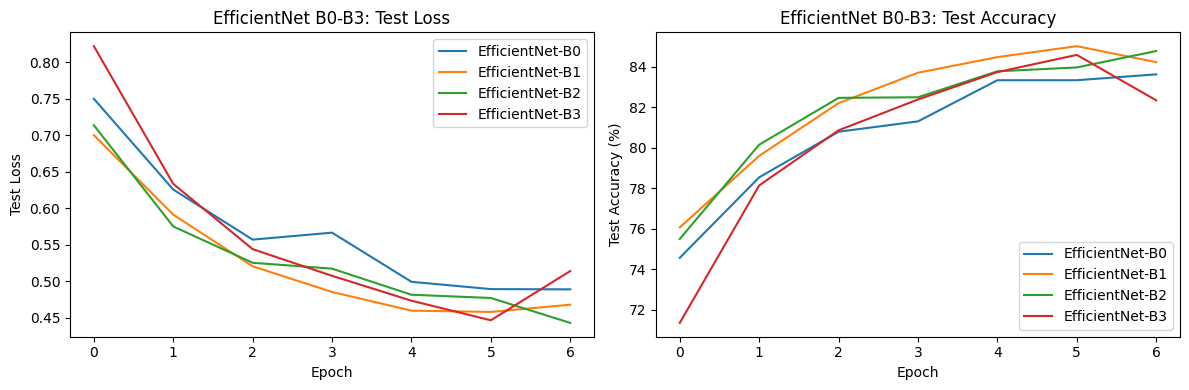


--- Итоговое сравнение (последняя эпоха) ---
EfficientNet-B0: Test Acc = 83.62% | Training time: 392.48s
EfficientNet-B1: Test Acc = 84.22% | Training time: 500.74s
EfficientNet-B2: Test Acc = 84.77% | Training time: 522.11s
EfficientNet-B3: Test Acc = 82.34% | Training time: 625.95s


In [7]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for variant in EFFICIENTNET_VARIANTS:
    plt.plot(histories[variant]['test_loss'], label=f'EfficientNet-{variant.upper()}')
plt.xlabel('Epoch')
plt.ylabel('Test Loss')
plt.title('EfficientNet B0-B3: Test Loss')
plt.legend()

plt.subplot(1, 2, 2)
for variant in EFFICIENTNET_VARIANTS:
    plt.plot(histories[variant]['test_acc'], label=f'EfficientNet-{variant.upper()}')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('EfficientNet B0-B3: Test Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- Итоговое сравнение (последняя эпоха) ---")
for variant in EFFICIENTNET_VARIANTS:
    final_acc = histories[variant]['test_acc'][-1]
    print(f"EfficientNet-{variant.upper()}: Test Acc = {final_acc:.2f}% | Training time: {train_times[variant]:.2f}s")



--- Classification Report (EfficientNet-B0) ---
              precision    recall  f1-score   support

           0     0.8060    0.8930    0.8472      1000
           1     0.8774    0.9230    0.8996      1000
           2     0.8448    0.7620    0.8013      1000
           3     0.6633    0.7270    0.6937      1000
           4     0.8097    0.8510    0.8298      1000
           5     0.7844    0.7460    0.7647      1000
           6     0.8537    0.8870    0.8700      1000
           7     0.9375    0.8100    0.8691      1000
           8     0.9535    0.8620    0.9055      1000
           9     0.8722    0.9010    0.8864      1000

    accuracy                         0.8362     10000
   macro avg     0.8403    0.8362    0.8367     10000
weighted avg     0.8403    0.8362    0.8367     10000



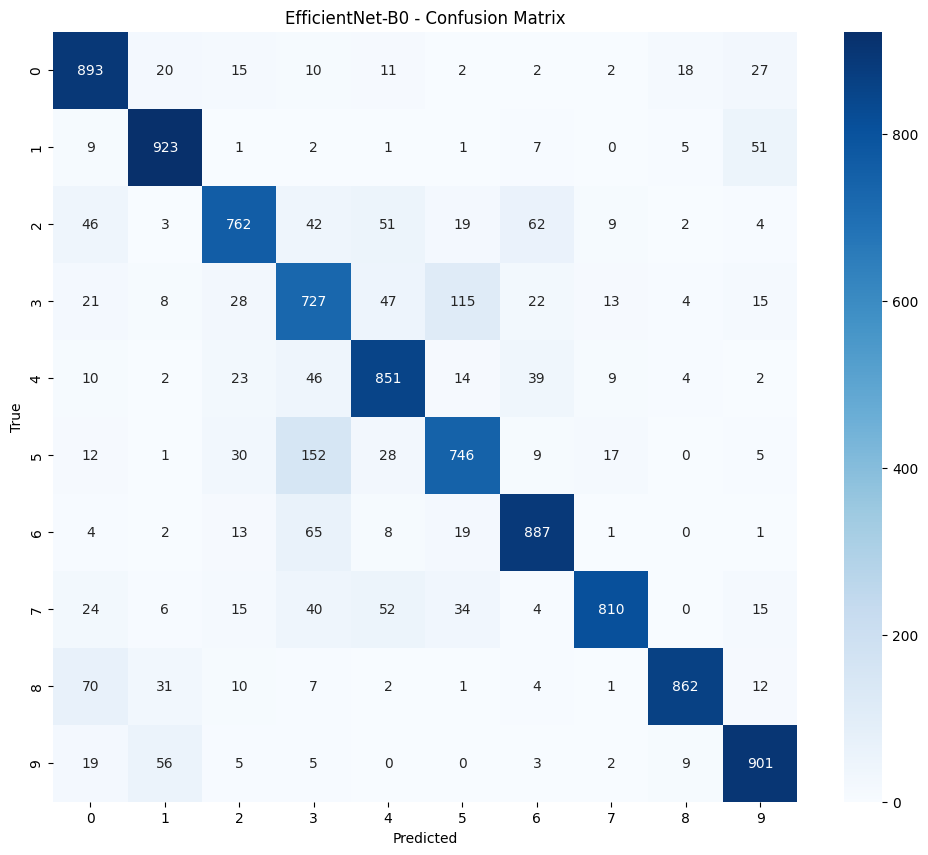


--- Classification Report (EfficientNet-B1) ---
              precision    recall  f1-score   support

           0     0.7922    0.9150    0.8492      1000
           1     0.9548    0.8880    0.9202      1000
           2     0.8090    0.8090    0.8090      1000
           3     0.7635    0.5780    0.6579      1000
           4     0.8246    0.8510    0.8376      1000
           5     0.7062    0.8390    0.7669      1000
           6     0.9033    0.8780    0.8905      1000
           7     0.9050    0.8480    0.8756      1000
           8     0.9140    0.8820    0.8977      1000
           9     0.8778    0.9340    0.9050      1000

    accuracy                         0.8422     10000
   macro avg     0.8451    0.8422    0.8410     10000
weighted avg     0.8451    0.8422    0.8410     10000



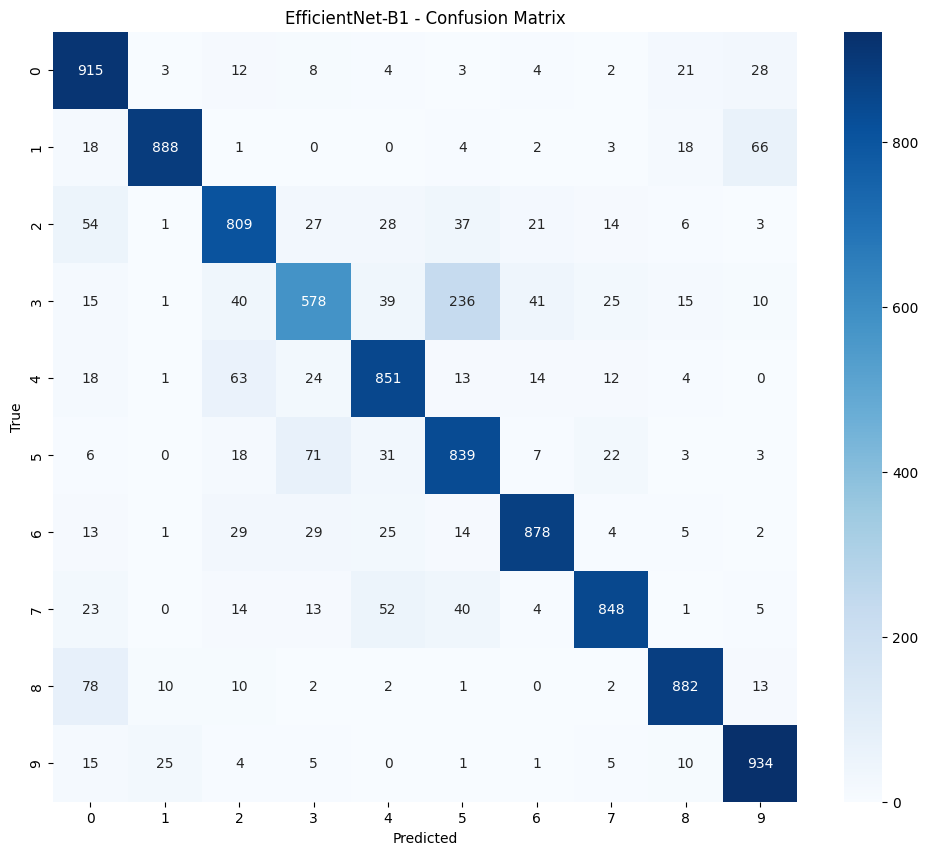


--- Classification Report (EfficientNet-B2) ---
              precision    recall  f1-score   support

           0     0.8917    0.8070    0.8472      1000
           1     0.9429    0.9090    0.9257      1000
           2     0.8615    0.7840    0.8209      1000
           3     0.7083    0.7380    0.7228      1000
           4     0.7754    0.8630    0.8168      1000
           5     0.7571    0.7730    0.7650      1000
           6     0.8726    0.8970    0.8846      1000
           7     0.9213    0.8310    0.8738      1000
           8     0.8827    0.9410    0.9109      1000
           9     0.8904    0.9340    0.9117      1000

    accuracy                         0.8477     10000
   macro avg     0.8504    0.8477    0.8480     10000
weighted avg     0.8504    0.8477    0.8480     10000



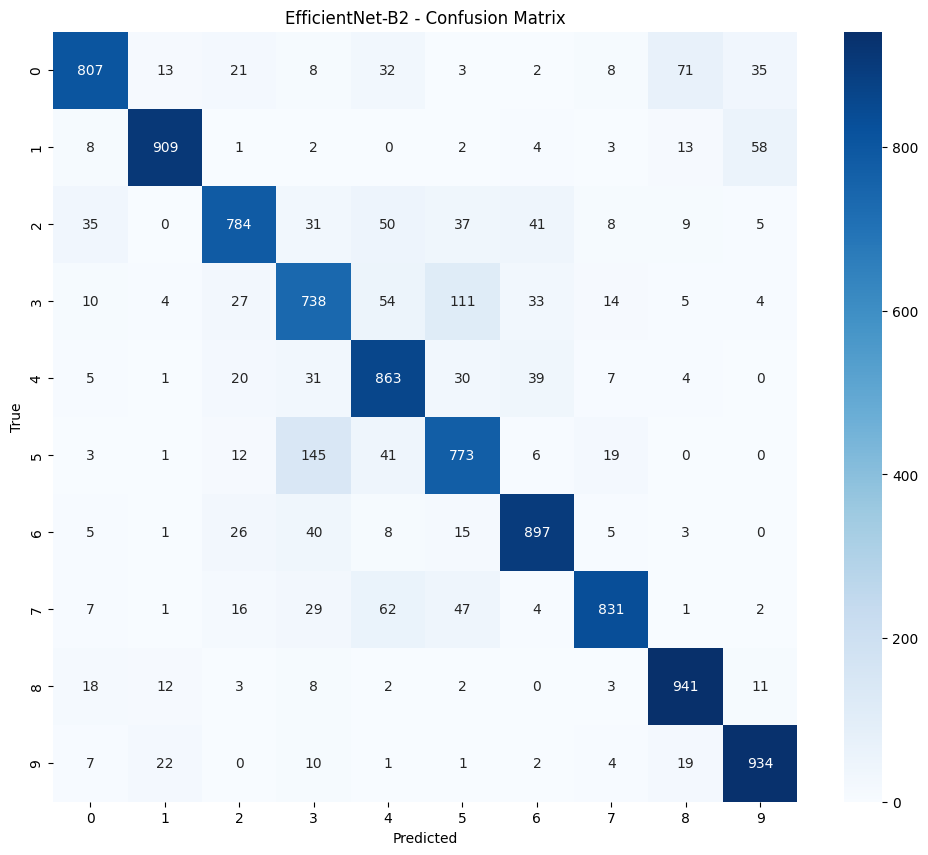


--- Classification Report (EfficientNet-B3) ---
              precision    recall  f1-score   support

           0     0.8816    0.8190    0.8491      1000
           1     0.9413    0.8820    0.9107      1000
           2     0.7283    0.8120    0.7678      1000
           3     0.7507    0.5630    0.6434      1000
           4     0.8086    0.8070    0.8078      1000
           5     0.6850    0.7850    0.7316      1000
           6     0.8663    0.8360    0.8509      1000
           7     0.8668    0.8850    0.8758      1000
           8     0.8195    0.9580    0.8834      1000
           9     0.9144    0.8870    0.9005      1000

    accuracy                         0.8234     10000
   macro avg     0.8262    0.8234    0.8221     10000
weighted avg     0.8262    0.8234    0.8221     10000



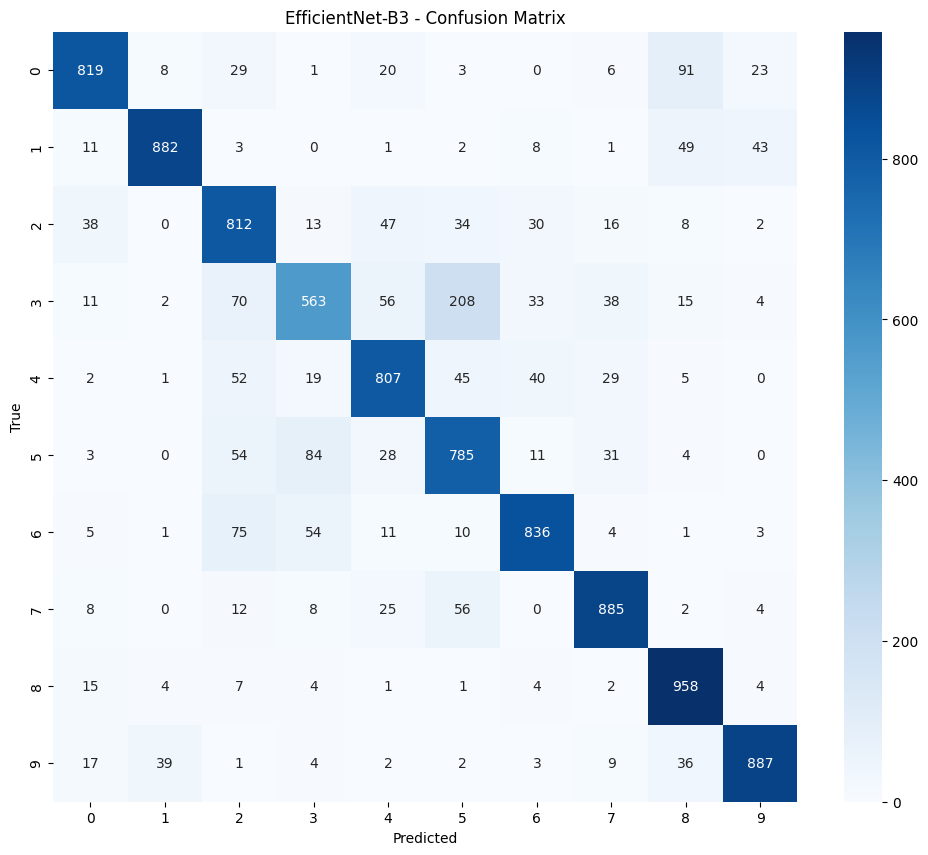

In [8]:
for variant in EFFICIENTNET_VARIANTS:
    model = models_dict[variant]
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(f"\n--- Classification Report (EfficientNet-{variant.upper()}) ---")
    print(classification_report(all_labels, all_preds, digits=4))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'EfficientNet-{variant.upper()} - Confusion Matrix')
    plt.show()



=== Robustness tests: EfficientNet-B0 ===

Clean: 83.62%

Gaussian Blur:
Blur σ=0.5               : 81.44%
Blur σ=1.0               : 52.25%
Blur σ=2.0               : 34.45%

Gaussian Noise:
Noise 0.05               : 67.01%
Noise 0.1                : 41.08%
Noise 0.2                : 19.23%
Noise 0.3                : 13.81%

Brightness:
Brightness -40%          : 80.11%
Brightness -20%          : 82.66%
Brightness +20%          : 83.02%
Brightness +40%          : 80.95%

Center Occlusion:
Occlusion 20%            : 78.13%
Occlusion 30%            : 68.80%
Occlusion 40%            : 60.16%


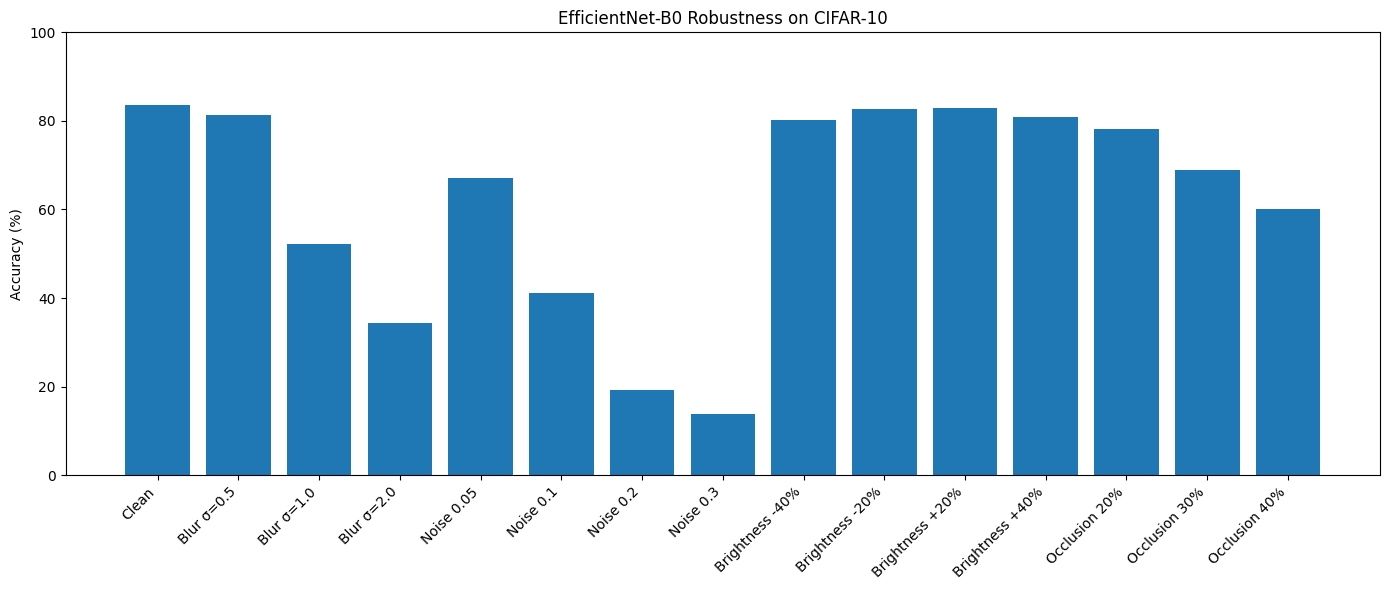


=== Robustness tests: EfficientNet-B1 ===

Clean: 84.22%

Gaussian Blur:
Blur σ=0.5               : 81.37%
Blur σ=1.0               : 46.33%
Blur σ=2.0               : 31.24%

Gaussian Noise:
Noise 0.05               : 69.99%
Noise 0.1                : 47.29%
Noise 0.2                : 16.55%
Noise 0.3                : 11.70%

Brightness:
Brightness -40%          : 81.87%
Brightness -20%          : 83.93%
Brightness +20%          : 83.05%
Brightness +40%          : 81.16%

Center Occlusion:
Occlusion 20%            : 75.94%
Occlusion 30%            : 65.45%
Occlusion 40%            : 55.08%


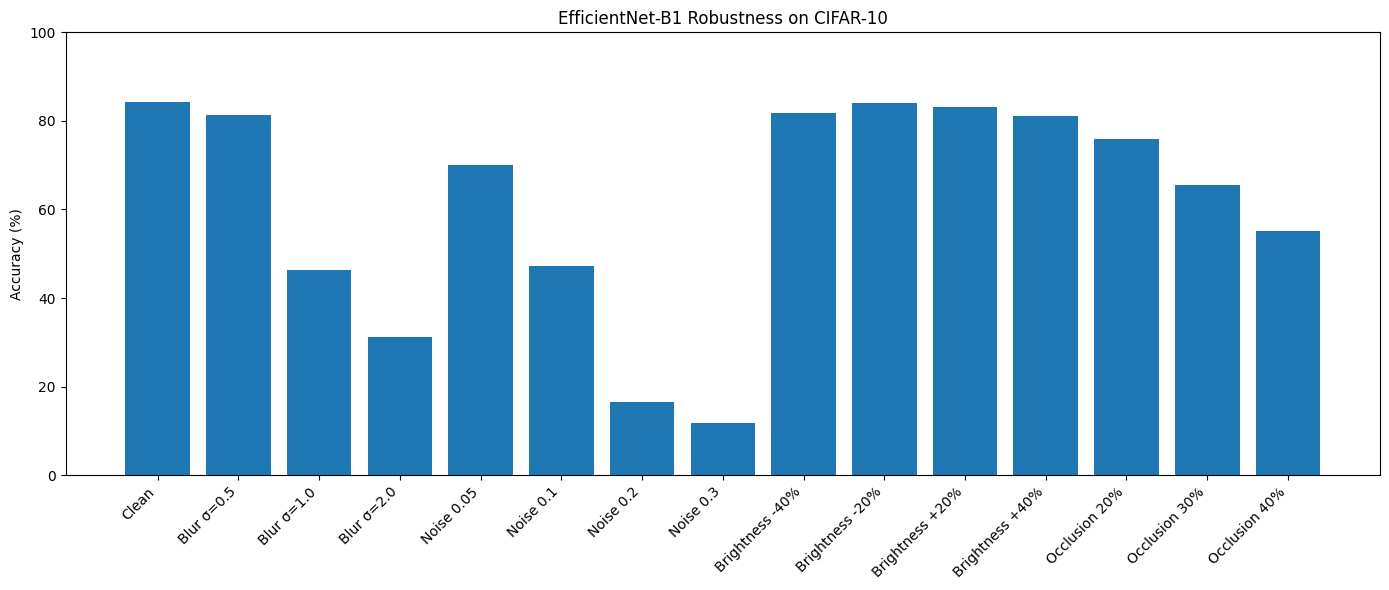


=== Robustness tests: EfficientNet-B2 ===

Clean: 84.77%

Gaussian Blur:
Blur σ=0.5               : 81.50%
Blur σ=1.0               : 42.32%
Blur σ=2.0               : 28.70%

Gaussian Noise:
Noise 0.05               : 60.25%
Noise 0.1                : 24.44%
Noise 0.2                : 13.19%
Noise 0.3                : 13.36%

Brightness:
Brightness -40%          : 80.37%
Brightness -20%          : 83.91%
Brightness +20%          : 84.44%
Brightness +40%          : 82.91%

Center Occlusion:
Occlusion 20%            : 78.75%
Occlusion 30%            : 71.15%
Occlusion 40%            : 59.28%


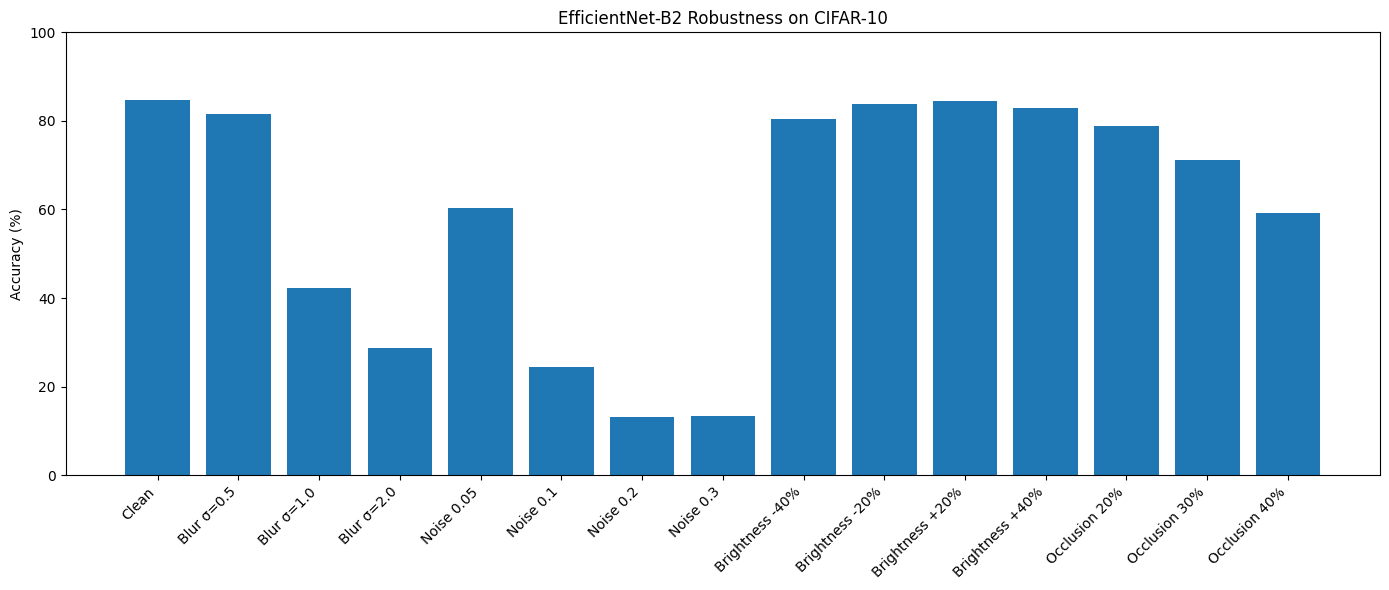


=== Robustness tests: EfficientNet-B3 ===

Clean: 82.34%

Gaussian Blur:
Blur σ=0.5               : 79.58%
Blur σ=1.0               : 47.62%
Blur σ=2.0               : 31.90%

Gaussian Noise:
Noise 0.05               : 65.26%
Noise 0.1                : 36.88%
Noise 0.2                : 12.52%
Noise 0.3                : 11.03%

Brightness:
Brightness -40%          : 80.82%
Brightness -20%          : 81.89%
Brightness +20%          : 81.95%
Brightness +40%          : 80.46%

Center Occlusion:
Occlusion 20%            : 77.00%
Occlusion 30%            : 69.73%
Occlusion 40%            : 60.68%


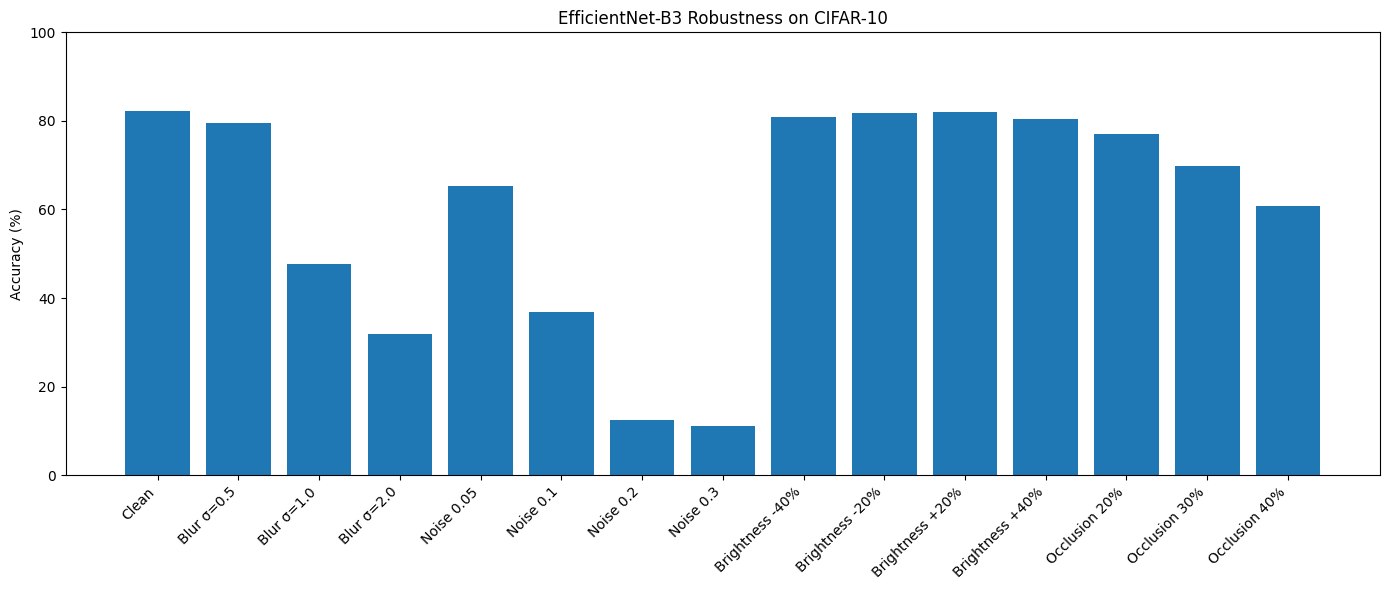

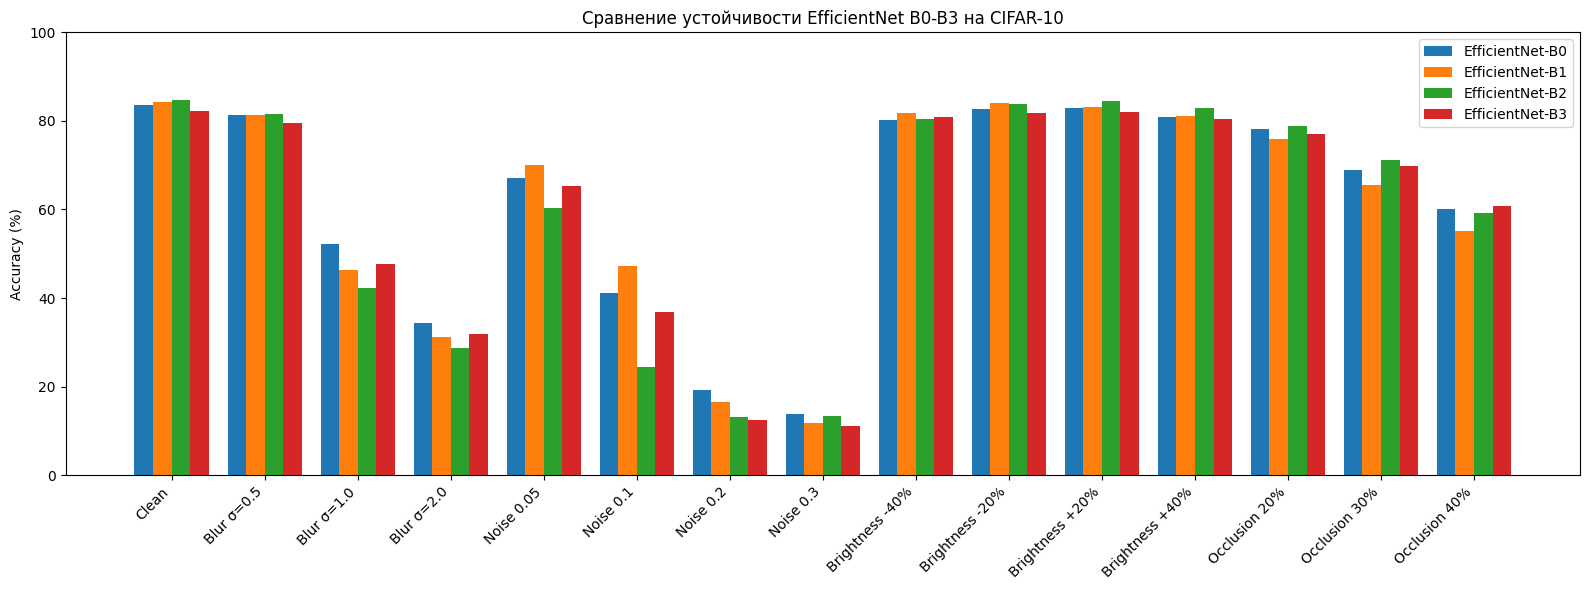

In [9]:
def evaluate_loader(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return 100.0 * correct / total

def make_corrupted_dataset(corruption='noise', severity=0.2):
    xs, ys = [], []
    dataset = datasets.CIFAR10(
        root=DATA_DIR,
        train=False,
        transform=transforms.ToTensor(),
        download=False
    )
    for x, y in dataset:
        if corruption == 'noise':
            x = torch.clamp(x + torch.randn_like(x) * severity, 0, 1)
        elif corruption == 'brightness':
            x = torch.clamp(x * (1.0 + severity), 0, 1)
        elif corruption == 'blur':
            x = transforms.functional.gaussian_blur(
                x,
                kernel_size=5,
                sigma=severity
            )
        elif corruption == 'occlusion':
            size = int(32 * severity)
            start = (32 - size) // 2
            x[:, start:start+size, start:start+size] = 0
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.tensor(ys)

def evaluate_corrupted(model, corruption, severity):
    xs, ys = make_corrupted_dataset(corruption, severity)
    mean = torch.tensor([0.4914, 0.4822, 0.4465])[:, None, None]
    std = torch.tensor([0.2470, 0.2435, 0.2616])[:, None, None]
    xs = (xs - mean) / std
    loader = DataLoader(
        torch.utils.data.TensorDataset(xs, ys),
        batch_size=BATCH_SIZE,
        shuffle=False
    )
    return evaluate_loader(model, loader)

robustness_results = {}

for variant in EFFICIENTNET_VARIANTS:
    model = models_dict[variant]
    base_acc = evaluate_loader(model, test_loader)

    blur_results = {}
    for sigma in [0.5, 1.0, 2.0]:
        blur_results[f'Blur σ={sigma}'] = evaluate_corrupted(model, 'blur', sigma)

    noise_results = {}
    for severity in [0.05, 0.10, 0.20, 0.30]:
        noise_results[f'Noise {severity}'] = evaluate_corrupted(model, 'noise', severity)

    brightness_results = {}
    for severity in [-0.40, -0.20, 0.20, 0.40]:
        brightness_results[f'Brightness {severity:+.0%}'] = evaluate_corrupted(
            model, 'brightness', severity
        )

    occlusion_results = {}
    for severity in [0.20, 0.30, 0.40]:
        occlusion_results[f'Occlusion {severity:.0%}'] = evaluate_corrupted(
            model, 'occlusion', severity
        )

    print(f'\n=== Robustness tests: EfficientNet-{variant.upper()} ===')
    print(f'\nClean: {base_acc:.2f}%')

    print('\nGaussian Blur:')
    for name, acc in blur_results.items():
        print(f'{name:25s}: {acc:.2f}%')

    print('\nGaussian Noise:')
    for name, acc in noise_results.items():
        print(f'{name:25s}: {acc:.2f}%')

    print('\nBrightness:')
    for name, acc in brightness_results.items():
        print(f'{name:25s}: {acc:.2f}%')

    print('\nCenter Occlusion:')
    for name, acc in occlusion_results.items():
        print(f'{name:25s}: {acc:.2f}%')

    robustness_results[variant] = {
        'Clean': base_acc,
        **blur_results,
        **noise_results,
        **brightness_results,
        **occlusion_results
    }

    plt.figure(figsize=(14, 6))
    plt.bar(robustness_results[variant].keys(), robustness_results[variant].values())
    plt.ylabel('Accuracy (%)')
    plt.title(f'EfficientNet-{variant.upper()} Robustness on CIFAR-10')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

# Сравнение устойчивости всех моделей на одном графике
categories = list(next(iter(robustness_results.values())).keys())
x = np.arange(len(categories))
width = 0.2

plt.figure(figsize=(16, 6))
for i, variant in enumerate(EFFICIENTNET_VARIANTS):
    plt.bar(x + i * width, [robustness_results[variant][c] for c in categories], width, label=f'EfficientNet-{variant.upper()}')
plt.xticks(x + width * 1.5, categories, rotation=45, ha='right')
plt.ylabel('Accuracy (%)')
plt.title('Сравнение устойчивости EfficientNet B0-B3 на CIFAR-10')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
import torch.nn.functional as F

def get_embedding_model(model):
    embedding_model = model
    embedding_model.classifier[1] = nn.Identity()  
    embedding_model.eval()
    return embedding_model

emb_model = get_embedding_model(models_dict['b3'])

def extract_embeddings(model, loader):
    embeddings = []
    labels = []
    with torch.no_grad():
        for images, ys in loader:
            images = images.to(device)
            emb = model(images)         
            embeddings.append(emb.cpu())
            labels.append(ys)
    return torch.cat(embeddings), torch.cat(labels)

embeddings, labels = extract_embeddings(emb_model, test_loader)
print(embeddings.shape)  

torch.Size([10000, 1536])


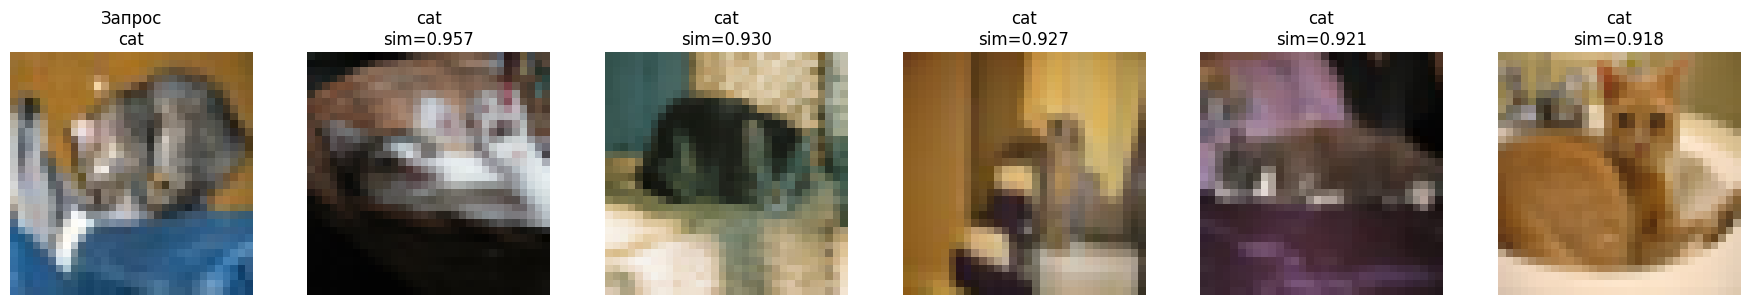

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

display_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=False, transform=transforms.ToTensor(), download=False
)

def show_similar(query_idx, embeddings, labels, dataset, top_k=5):
    sims = F.cosine_similarity(embeddings[query_idx].unsqueeze(0), embeddings)
    top_indices = torch.topk(sims, top_k + 1).indices[1:] 

    fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 3))

    query_img, _ = dataset[query_idx]
    axes[0].imshow(query_img.permute(1, 2, 0))
    axes[0].set_title(f"Запрос\n{class_names[labels[query_idx]]}")
    axes[0].axis('off')

    for i, idx in enumerate(top_indices):
        img, _ = dataset[idx]
        axes[i + 1].imshow(img.permute(1, 2, 0))
        axes[i + 1].set_title(f"{class_names[labels[idx]]}\nsim={sims[idx]:.3f}")
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

show_similar(query_idx=0, embeddings=embeddings, labels=labels, dataset=display_dataset, top_k=5)